### Практическая работа №8: Разделительная кластеризация

Выполнил: Чашин Денис, ЕТ-128

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn_extra.cluster import KMedoids

### Кластеризация данных с помощью алгоритма k‑Means

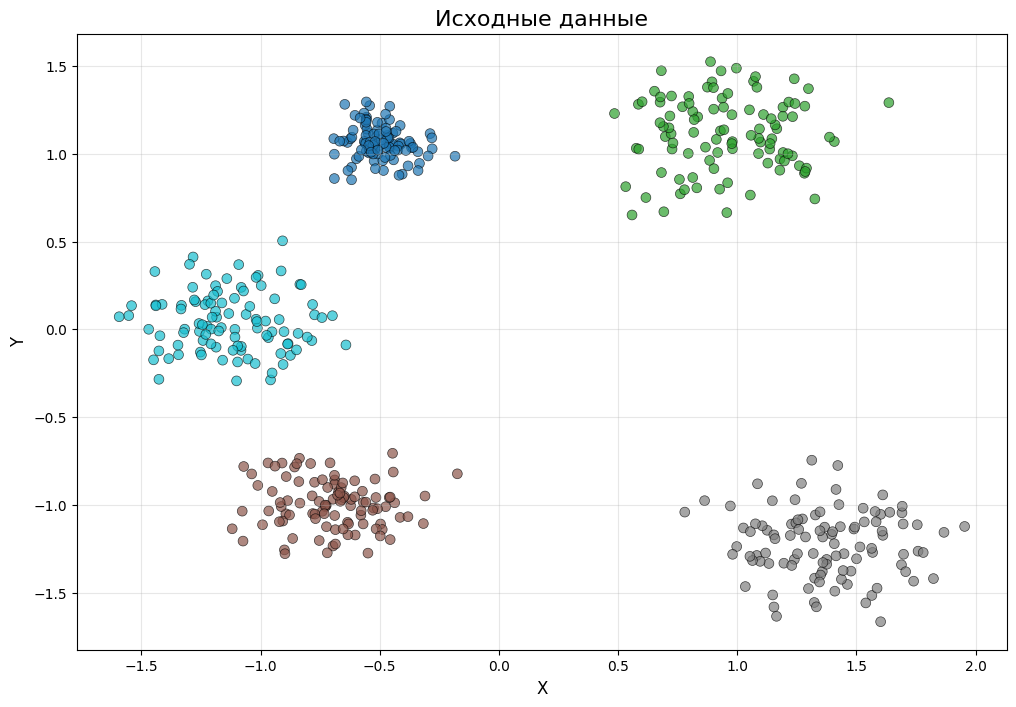

Размерность данных: (500, 2)
Количество точек: 500


In [83]:
np.random.seed(25)
X, y_true = make_blobs(n_samples=500,
                       centers=5,
                       cluster_std=[0.7, 1.5, 1.2, 1.5, 1.4],
                       random_state=31)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.rcParams['figure.figsize'] = (16, 10)
plt.figure(figsize=(12, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_true, cmap='tab10',
           s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
plt.title('Исходные данные', fontsize=16)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Размерность данных: {X_scaled.shape}")
print(f"Количество точек: {len(X_scaled)}")

In [71]:
def plot_clustering_results(X, labels, centers=None, title="", ax=None):
    if ax is None:
        ax = plt.gca()

    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], s=40, alpha=0.7,
                  edgecolors='white', linewidth=0.5)

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200,
                  marker='*', edgecolors='white', linewidth=2,
                  label='Центры кластеров')

    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.5)

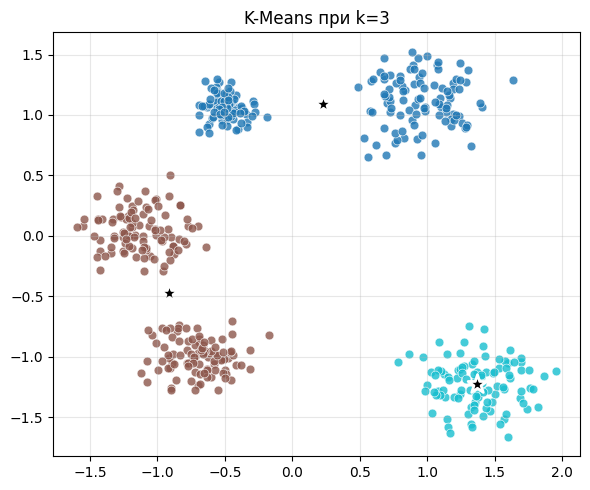

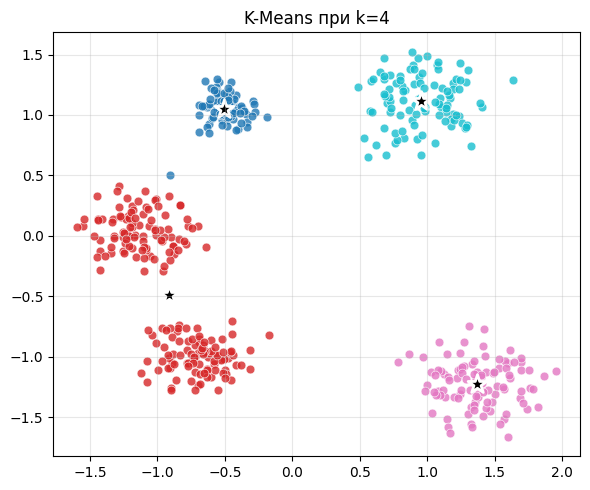

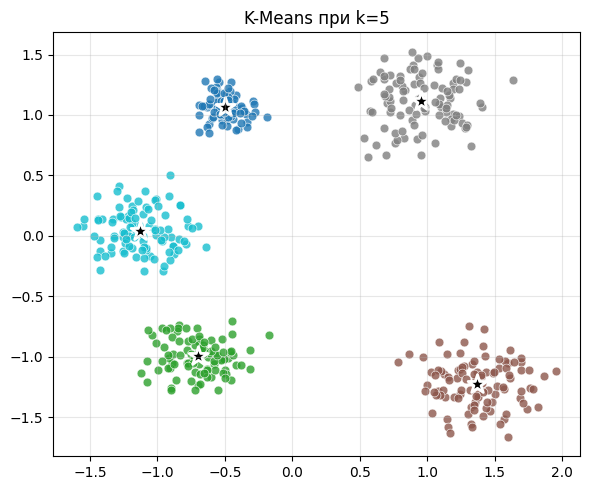

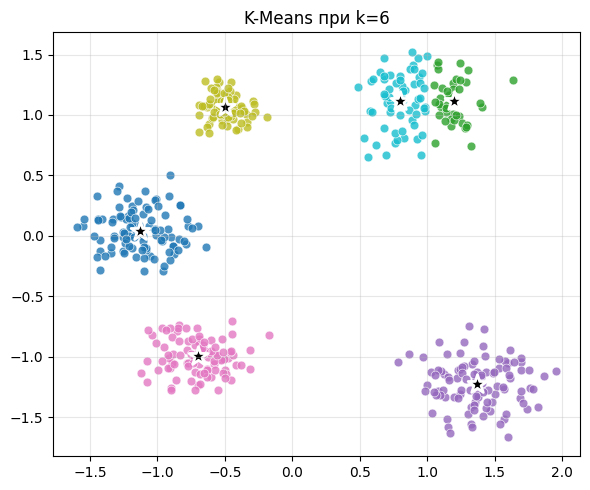

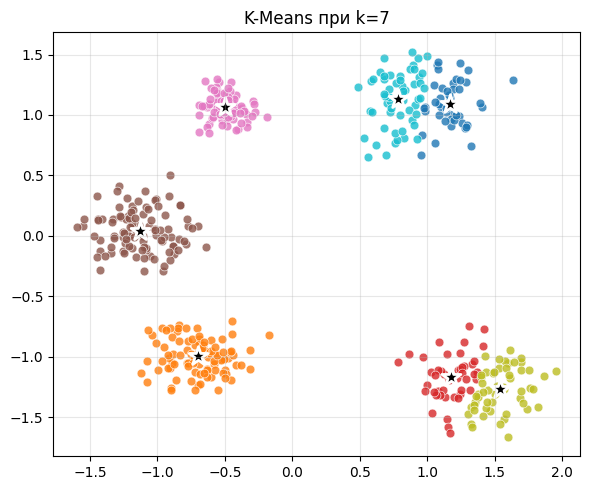

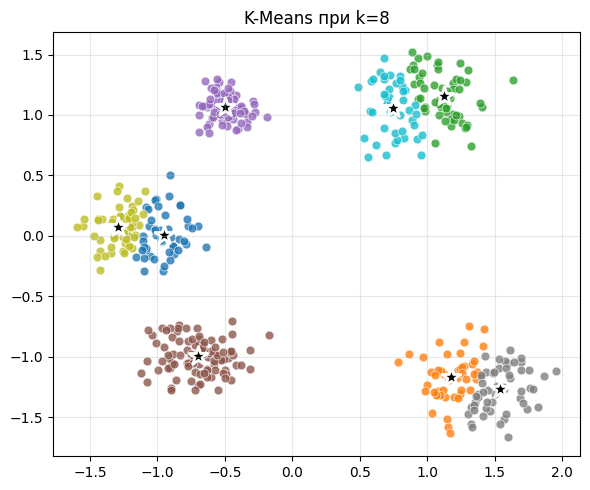

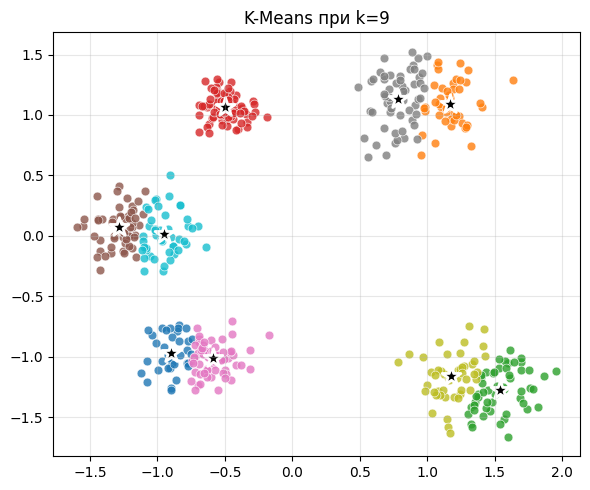

In [84]:
k_values = range(3, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(6, 5))
    ax = plt.gca()

    plot_clustering_results(
        X_scaled,
        labels_kmeans,
        kmeans.cluster_centers_,
        f'K-Means: k={k}',
        ax
    )

    plt.title(f'K-Means при k={k}')
    plt.tight_layout()
    plt.show()

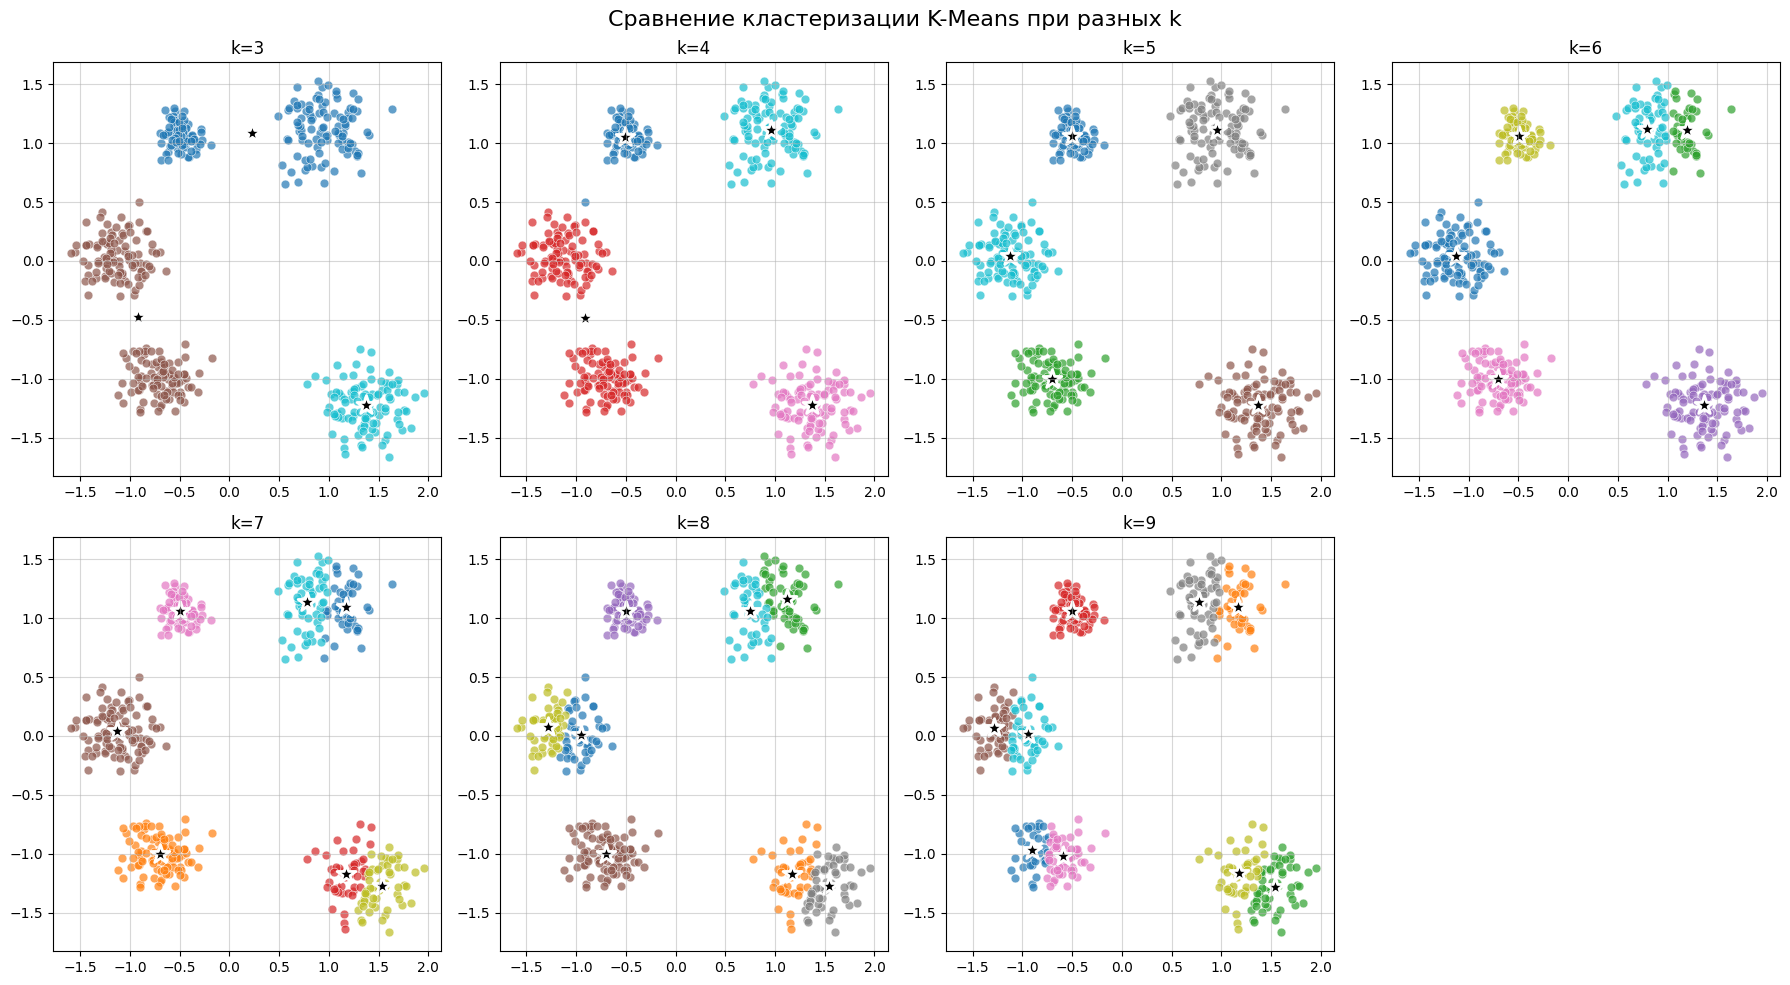

In [73]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_scaled)

    plot_clustering_results(
        X_scaled,
        labels_kmeans,
        kmeans.cluster_centers_,
        f'k={k}',
        axes[idx]
    )
axes[-1].remove()

plt.suptitle('Сравнение кластеризации K-Means при разных k', fontsize=16)
plt.tight_layout()
plt.show()

### Кластеризация зашумленного набора данных с помощью алгоритмов k‑Means и k‑Medoids

In [74]:
def add_noise(data, noise_percentage, noise_magnitude=0.5):
    data_noisy = data.copy()
    n_points = len(data)
    n_noisy = int(n_points * noise_percentage / 100)

    noisy_indices = np.random.choice(n_points, n_noisy, replace=False)

    for idx in noisy_indices:
        noise = np.random.randn(data.shape[1]) * noise_magnitude
        data_noisy[idx] += noise

    return data_noisy, noisy_indices

In [76]:
# Передираем все варианты

noise_percentages = [0, 1, 3, 5, 10] # Процент шума
k_values = [3, 4, 5, 6, 7, 8, 9]     # Количество соседей


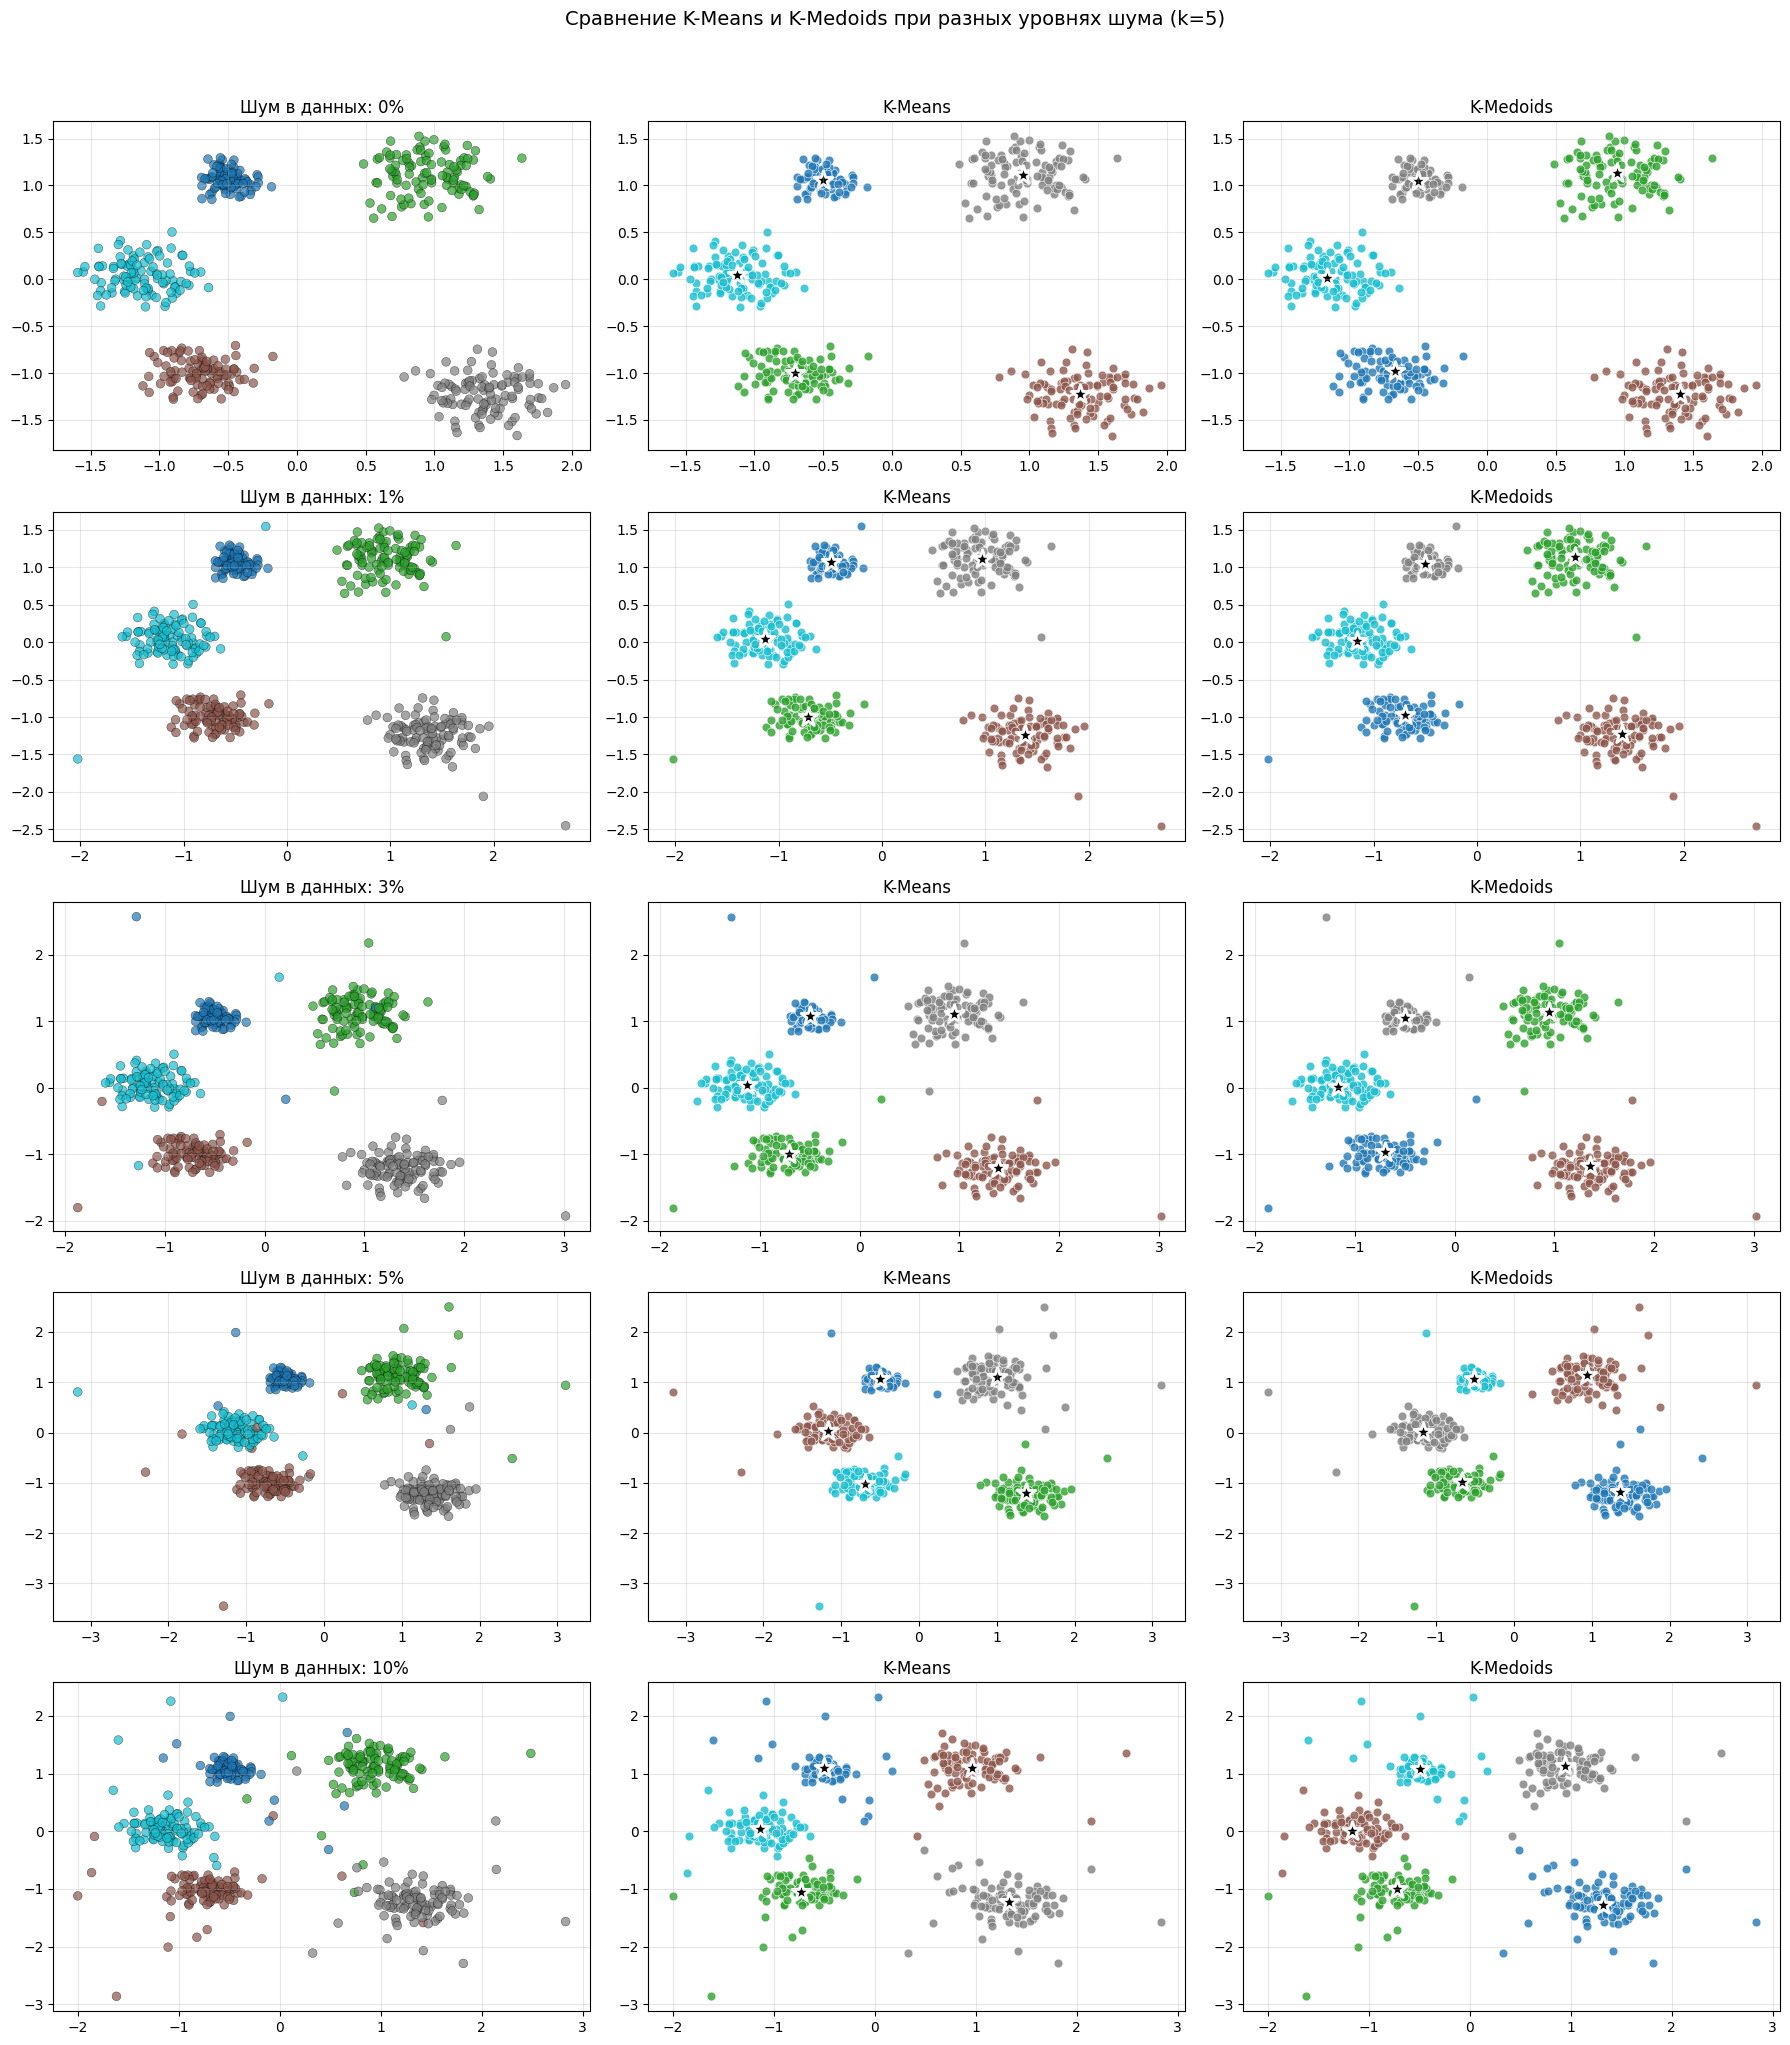

In [86]:
fixed_k = 5
noise_levels = [0, 1, 3, 5, 10]

fig, axes = plt.subplots(len(noise_levels), 3, figsize=(18, 20))

for idx, noise_pct in enumerate(noise_levels):
    X_noisy, _ = add_noise(X_scaled, noise_pct, noise_magnitude=1.0)

    # K-Means
    kmeans = KMeans(n_clusters=fixed_k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_noisy)

    # K-Medoids
    kmedoids = KMedoids(n_clusters=fixed_k, random_state=42, method='pam')
    labels_kmedoids = kmedoids.fit_predict(X_noisy)

    # Зашумленные данные
    scatter = axes[idx, 0].scatter(X_noisy[:, 0], X_noisy[:, 1],
                                  c=y_true, cmap='tab10',
                                  s=40, alpha=0.7, edgecolors='black', linewidth=0.3)
    axes[idx, 0].set_title(f'Шум в данных: {noise_pct}%', fontsize=12)
    axes[idx, 0].grid(True, alpha=0.3)

    # K-Means результат
    plot_clustering_results(X_noisy, labels_kmeans, kmeans.cluster_centers_,
                          f'K-Means',
                          axes[idx, 1])

    # K-Medoids результат
    plot_clustering_results(X_noisy, labels_kmedoids, kmedoids.cluster_centers_,
                          f'K-Medoids',
                          axes[idx, 2])

plt.suptitle('Сравнение K-Means и K-Medoids при разных уровнях шума (k=5)',
            fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Кластеризация набора данных из задания о плотностной кластеризации (невыпуклые кластеры)

In [78]:
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

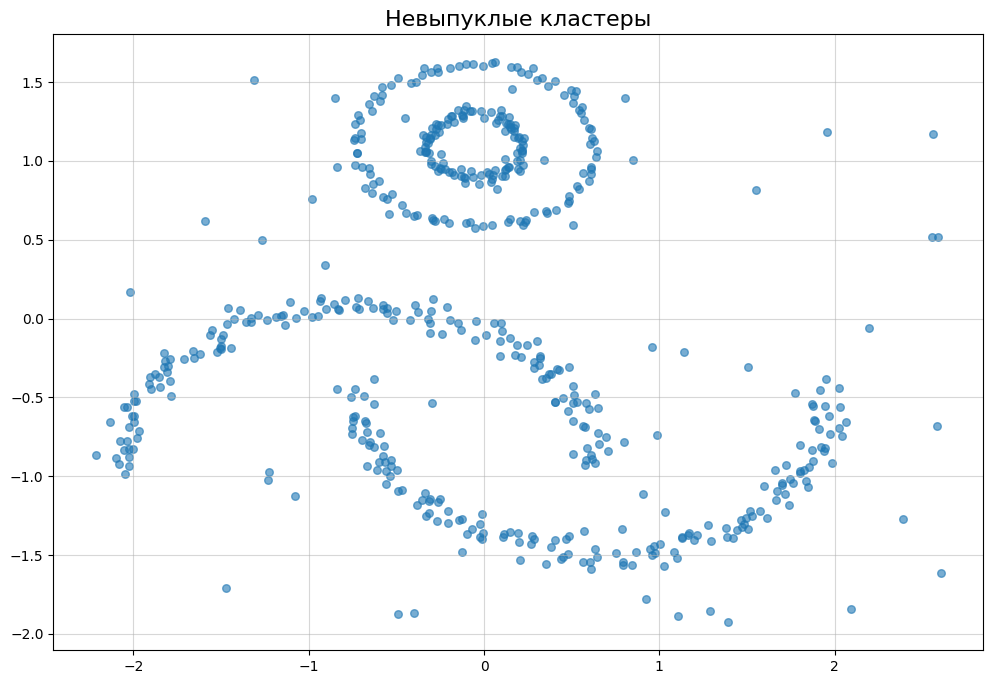

(550, 2)

In [87]:
circles_data, circles_labels = make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=29)
circles_data = circles_data + np.array([1, 4])
moons_data, moons_labels = make_moons(n_samples=300, noise=0.05, random_state=29)
moons_data = moons_data * 2
noise_data = np.random.uniform(low=-2, high=5, size=(50, 2))
X2 = np.vstack([moons_data, circles_data, noise_data])
X2 = StandardScaler().fit_transform(X2)

plt.figure(figsize=(12, 8))
plt.scatter(X2[:, 0], X2[:, 1], alpha=0.6, s=30)
plt.title('Невыпуклые кластеры', fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()

X2.shape

In [80]:
# Функция вывода результатов
def plot_clustering_results(X, labels, centers=None, title="", ax=None):
    if ax is None:
        ax = plt.gca()

    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1]) if -1 in unique_labels else len(unique_labels)

    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'
            marker = 'x'
            size = 30
            alpha = 0.5
        else:
            marker = 'o'
            size = 40
            alpha = 0.8

        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size,
                  alpha=alpha, edgecolors='white', linewidth=0.5)

    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], c='black', s=200,
                  marker='*', edgecolors='white', linewidth=2,
                  label='Центры' if 'Центры' not in ax.get_legend_handles_labels()[1] else "")

    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

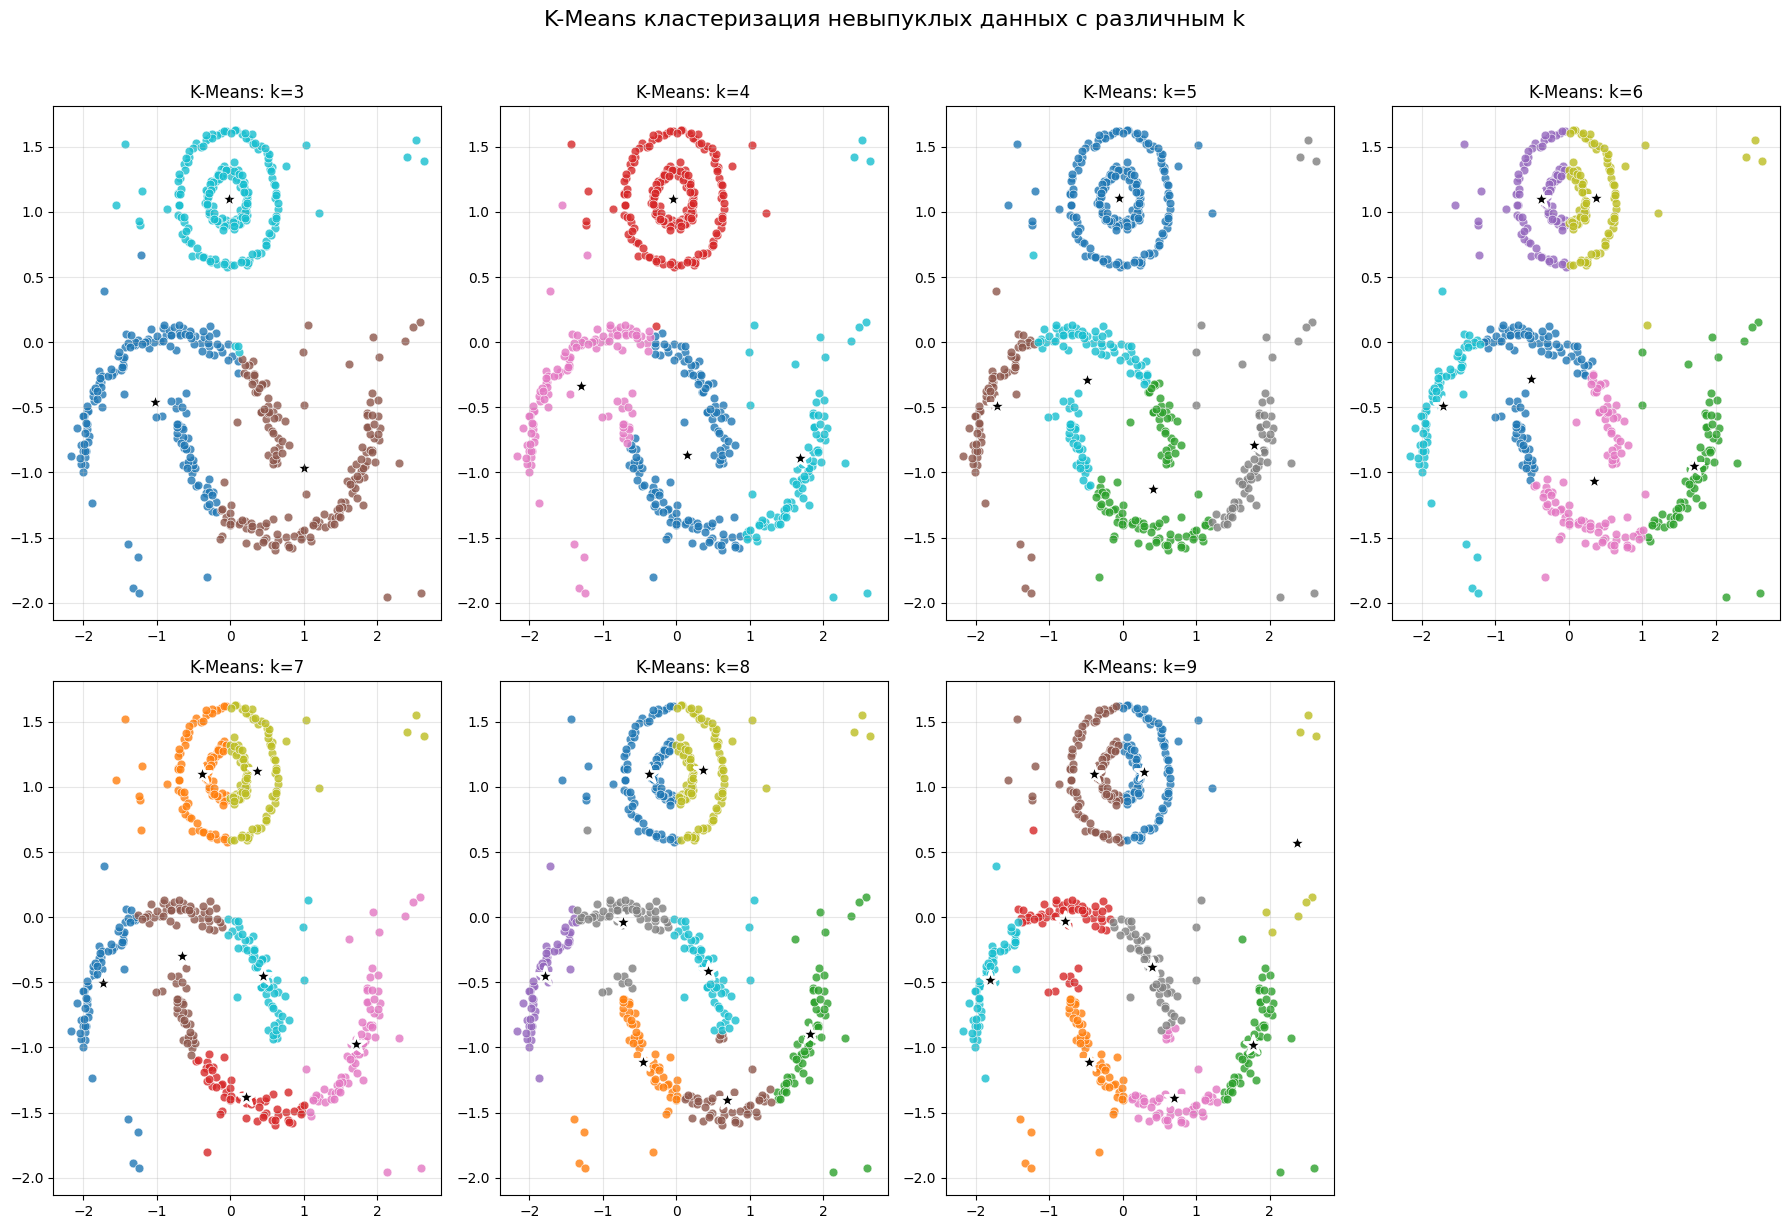

In [81]:
# K-Means

k_values = range(3, 10)
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X2)

    # Визуализация
    plot_clustering_results(X2, labels_kmeans, kmeans.cluster_centers_,
                          f'K-Means: k={k}',
                          axes[idx])

axes[-1].remove()
plt.suptitle('K-Means кластеризация невыпуклых данных с различным k', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

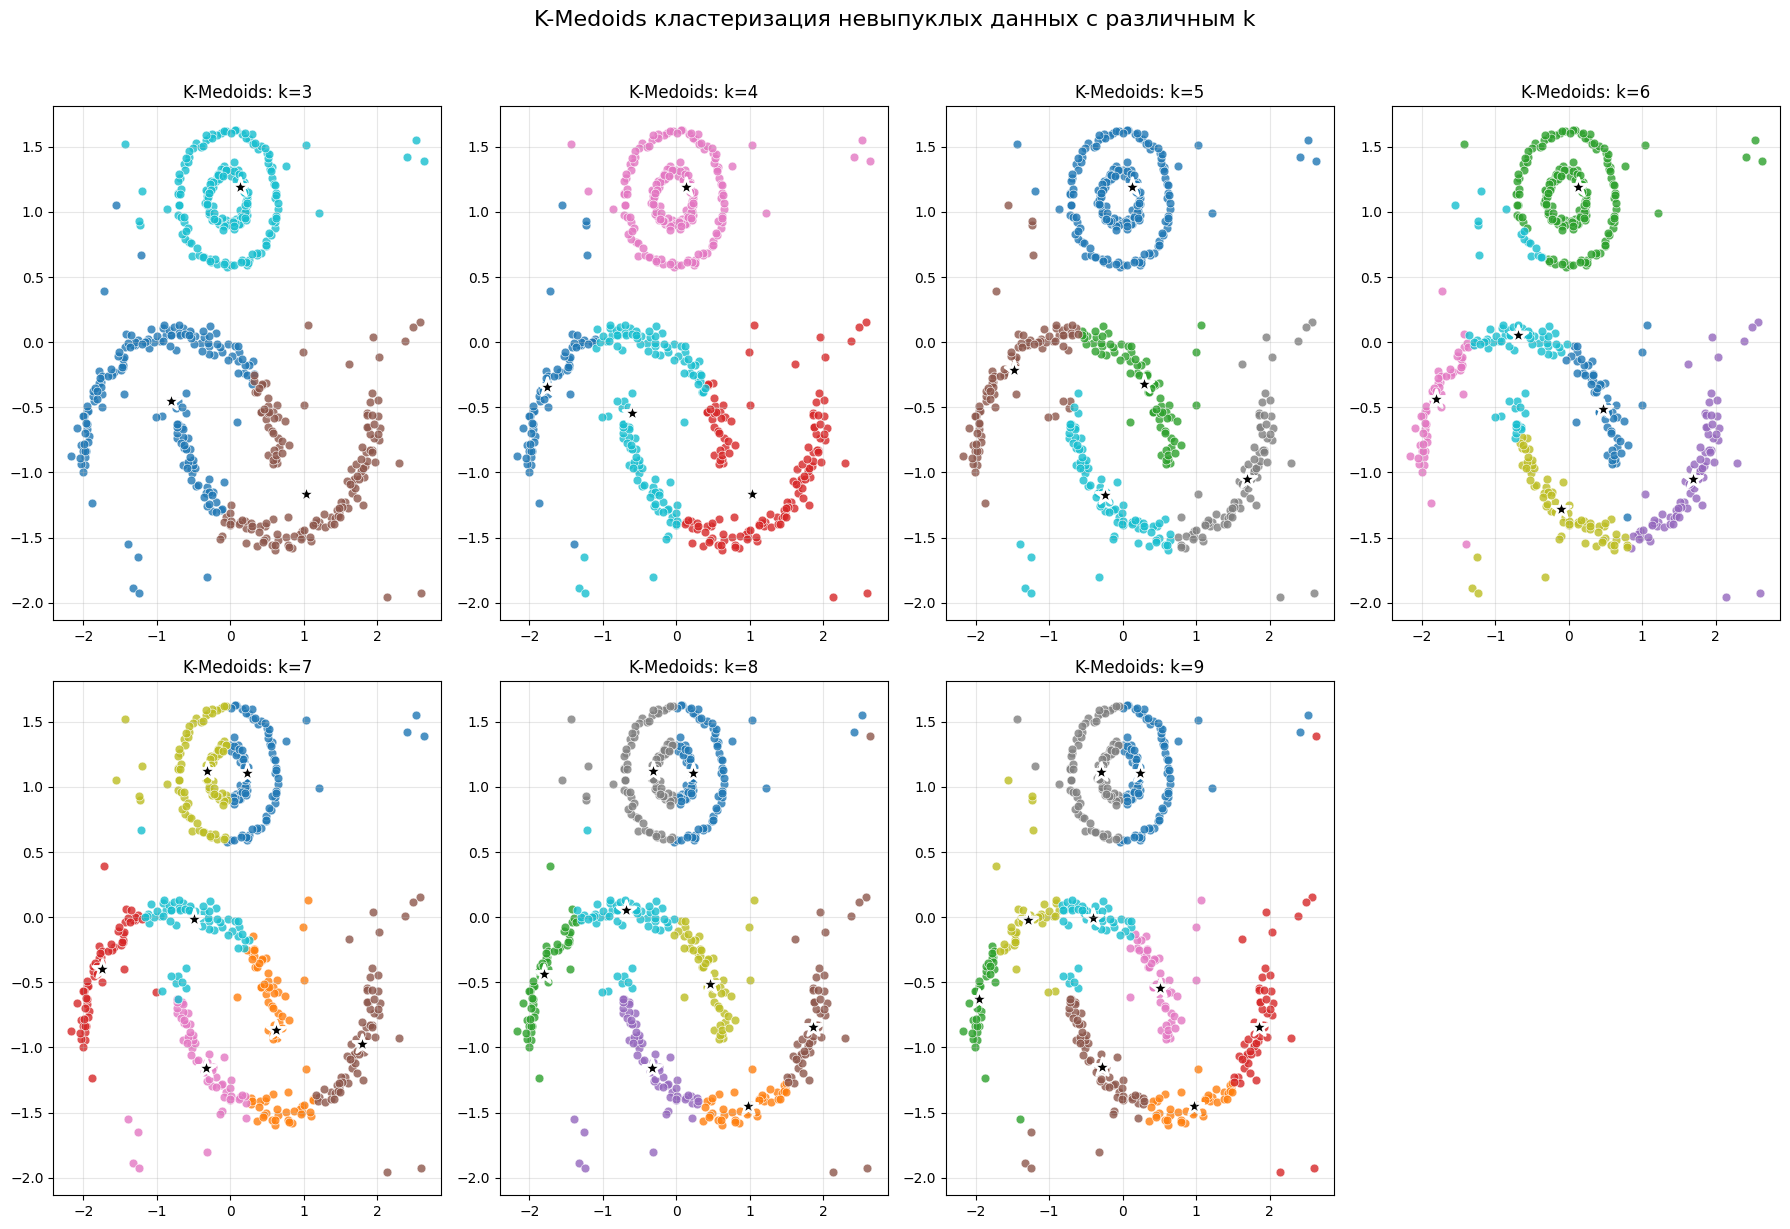

In [82]:
# k-medoids

fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values):
    kmedoids = KMedoids(n_clusters=k, random_state=42, method='pam')
    labels_kmedoids = kmedoids.fit_predict(X2)

    # Визуализация
    plot_clustering_results(X2, labels_kmedoids, kmedoids.cluster_centers_,
                          f'K-Medoids: k={k}',
                          axes[idx])

axes[-1].remove()
plt.suptitle('K-Medoids кластеризация невыпуклых данных с различным k', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()